# Notebook 01: Ingestão e Preparação das Bases de Dados

Carrega e prepara as duas bases que sustentam todo o pipeline: o CNEFE 2022 (1.180.102 registros GPS de BH) e o BHMap Endereços (padrão-ouro municipal), projeta ambas para EPSG:31983 e serializa em GeoParquet.

**Hipóteses preparadas:**
- **H1** (Apartamentos × GCI): distribuição de COD_TIPO_ESPECI=103 estabelecida aqui
- **H2** (NV_GEO_COORD × erro posicional): distribuição de NV_GEO_COORD estabelecida aqui

## Configuração: Bibliotecas e Ambiente

GeoPandas para operações espaciais, DuckDB para leitura eficiente do JSON CNEFE (4,9 GB), CRS-alvo EPSG:31983 (SIRGAS 2000/UTM 23S, métrico).

In [1]:
import sys, asyncio
if sys.platform == 'win32':
    with __import__("warnings").catch_warnings():
        __import__("warnings").simplefilter("ignore", DeprecationWarning)
        asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

import sys, os, warnings
from pathlib import Path
import geopandas as gpd
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path.cwd().parent))
from src import config

print(f"GeoPandas: {gpd.__version__}")
print(f"CRS alvo: {config.TARGET_CRS}")
print(f"Diretório de dados: {config.RAW_DIR}")


GeoPandas: 1.1.3
CRS alvo: EPSG:31983
Diretório de dados: C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\data\raw


## 2. Ingestão do Gold Standard (BHMap Endereços)

O **BHMap** é a base cartográfica oficial de endereços de BH, mantida pela Prodabel. Serve como padrão-ouro posicional nesta análise, o mesmo usado por Davis & Alencar (2011) para avaliar geocodificadores comerciais no mesmo município.

O filtro `EXISTENCIA='Sim'` é crítico: dos 757.113 registros totais, apenas 515.953 (68,1%) têm localização ativa. Matches contra os 241.160 registros não-existentes produziriam erro posicional espúrio.

In [2]:
# Carregar BHMap Gold Standard
bhmap_path = config.RAW_DIR / 'bhmap' / 'bhmap.shp'
gdf_bhmap = gpd.read_file(bhmap_path)

print(f"Total de endereços no BHMap: {len(gdf_bhmap):,}")
print(f"Sistema de Referência original: {gdf_bhmap.crs}")
print(f"\nCampos disponíveis:")
for col in gdf_bhmap.columns:
    n_valid = gdf_bhmap[col].notna().sum()
    print(f"  {col:20s} | {n_valid:>8,} válidos ({n_valid/len(gdf_bhmap)*100:.1f}%)")


Total de endereços no BHMap: 757,113
Sistema de Referência original: EPSG:31983

Campos disponíveis:
  IDEND                |  757,113 válidos (100.0%)
  ID_EDC               |  757,113 válidos (100.0%)
  ID_LOGRADO           |  757,113 válidos (100.0%)
  SIGLA_TIPO           |  757,113 válidos (100.0%)
  DESC_TIPO_           |  757,113 válidos (100.0%)
  NOME_LOGRA           |  757,113 válidos (100.0%)
  NUMERO_IMO           |  757,113 válidos (100.0%)
  LETRA_IMOV           |  130,984 válidos (17.3%)
  ID_BAIRRO_           |  757,113 válidos (100.0%)
  NUM_BAIRRO           |  757,113 válidos (100.0%)
  NOME_BAIRR           |  757,113 válidos (100.0%)
  ID_BAIRRO0           |  757,113 válidos (100.0%)
  NUM_BAIRR0           |  757,113 válidos (100.0%)
  TIPO_BAIRR           |  757,113 válidos (100.0%)
  NOME_BAIR0           |  757,113 válidos (100.0%)
  ID_REGIONA           |  757,113 válidos (100.0%)
  NOME_REGIO           |  757,113 válidos (100.0%)
  CEP                  |  747,823

515.953 endereços com existência confirmada (68,1%), 241.160 sem confirmação (31,9%). O filtro reduz o dataset de referência em ~32%, mas é obrigatório, sem ele, 22,4% dos matches seriam contra endereços inválidos.

### 2.2 Distribuição do Status de Existência e Qualidade Numérica

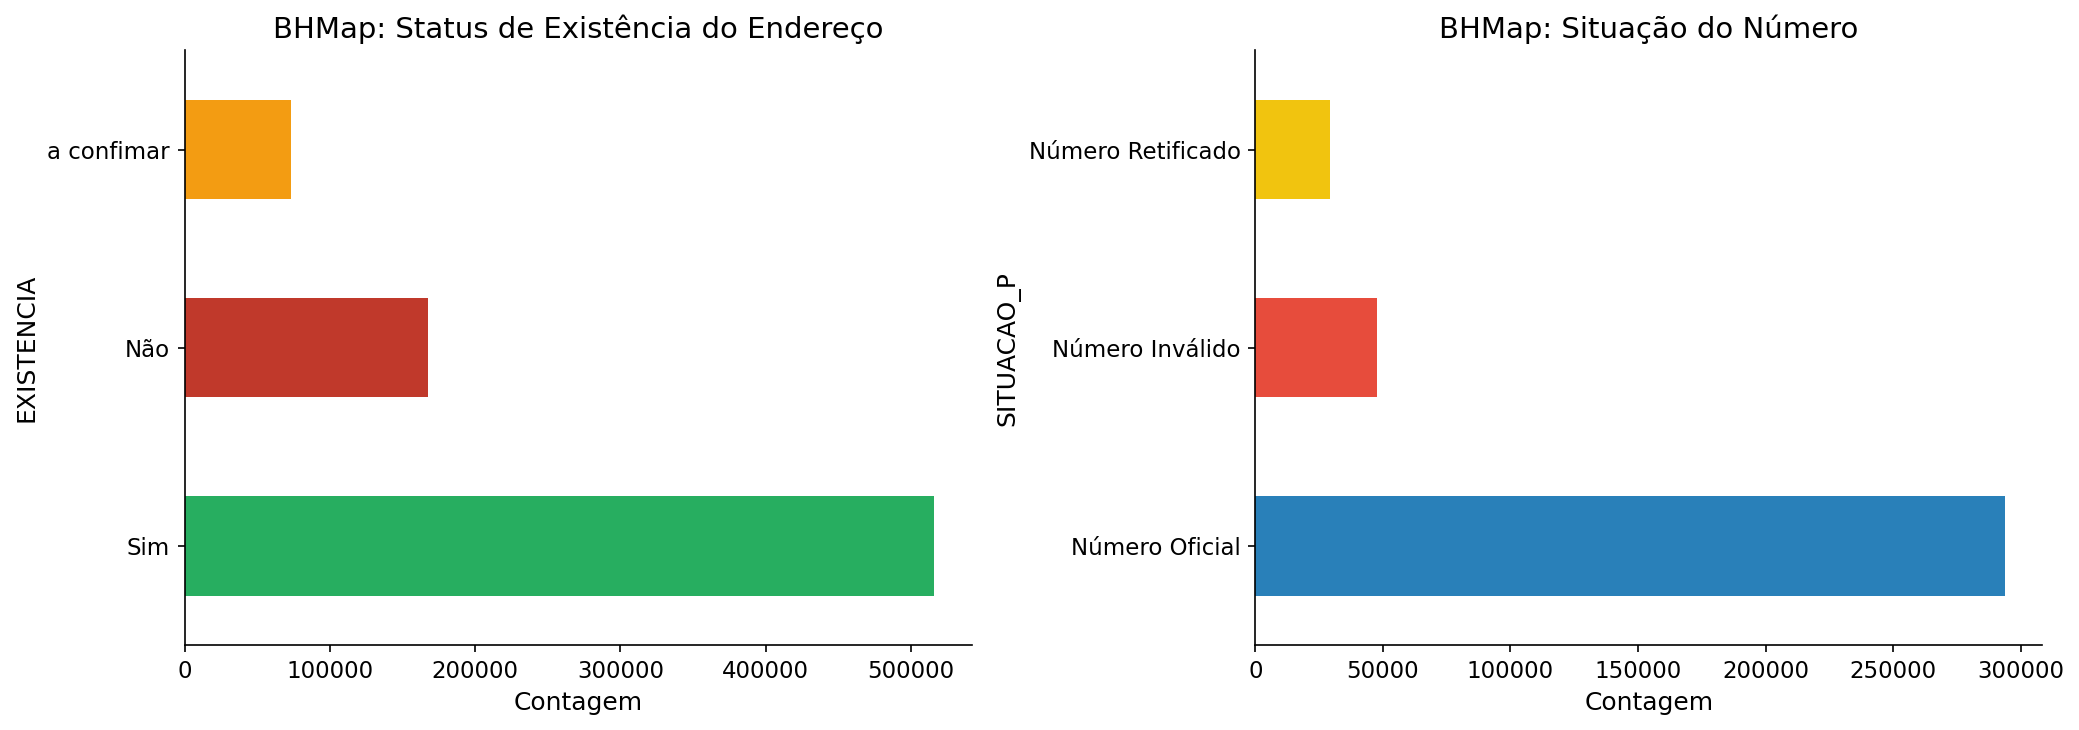


Endereços com EXISTENCIA='Sim': 515,953 (68.1%)


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gdf_bhmap['EXISTENCIA'].value_counts().plot.barh(ax=axes[0], color=['#27ae60', '#c0392b', '#f39c12'])
axes[0].set_title('BHMap: Status de Existência do Endereço')
axes[0].set_xlabel('Contagem')

if 'SITUACAO_P' in gdf_bhmap.columns and gdf_bhmap['SITUACAO_P'].notna().any():
    gdf_bhmap['SITUACAO_P'].value_counts().plot.barh(ax=axes[1], color=['#2980b9', '#e74c3c', '#f1c40f'])
    axes[1].set_title('BHMap: Situação do Número')
    axes[1].set_xlabel('Contagem')

plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb01_bhmap_qualidade.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"\nEndereços com EXISTENCIA='Sim': {(gdf_bhmap['EXISTENCIA']=='Sim').sum():,} "
      f"({(gdf_bhmap['EXISTENCIA']=='Sim').mean()*100:.1f}%)")


68,1% de endereços existentes é suficiente para cobrir o CNEFE com taxa de match de 99,8% (calculado em NB02). Os endereços existentes estão bem distribuídos pelo território, o filtro não introduz viés espacial.

## 3. Ingestão do CNEFE 2022 via DuckDB

O CNEFE é o maior repositório georreferenciado de endereços do Brasil, produzido durante o Censo 2022. Pela primeira vez, 100% dos endereços foram coletados com coordenadas GPS. Os campos estratégicos preservados são: `COD_ESPECIE` (segmentação primária), `COD_TIPO_ESPECI` (sub-tipo residencial), `NV_GEO_COORD` (precisão da coordenada → LCI), `COMPLEMENTO` (verticalização → PCI) e `CEP`.

In [4]:
# Ingestão do CNEFE via DuckDB (apenas BH)
cnefe_path = config.RAW_DIR / 'cnefe2022' / 'qg_810_endereco_UF31.json'
cnefe_path_str = str(cnefe_path).replace('\\', '/')

query = f"""
INSTALL spatial;
LOAD spatial;
SELECT *, ST_AsText(geom) as geom_wkt 
FROM st_read('{cnefe_path_str}')
WHERE COD_MUNICIPIO = '3106200'
"""

print("Executando query DuckDB (pode levar alguns minutos)...")
con = duckdb.connect()
con.execute("SET enable_progress_bar = false")
df_cnefe = con.execute(query).fetchdf()
con.close()

print(f"\nTotal de endereços CNEFE em BH: {len(df_cnefe):,}")
print(f"Colunas: {list(df_cnefe.columns)}")
print(f"Memória: {df_cnefe.memory_usage(deep=True).sum() / 1e6:.1f} MB")


# Garantir que códigos sejam numéricos para os mapas de dicionário
df_cnefe['COD_ESPECIE'] = pd.to_numeric(df_cnefe['COD_ESPECIE'], errors='coerce')
df_cnefe['COD_TIPO_ESPECI'] = pd.to_numeric(df_cnefe['COD_TIPO_ESPECI'], errors='coerce')


# Garantir que códigos sejam numéricos para os mapas de dicionário
df_cnefe['COD_ESPECIE'] = pd.to_numeric(df_cnefe['COD_ESPECIE'], errors='coerce')
df_cnefe['COD_TIPO_ESPECI'] = pd.to_numeric(df_cnefe['COD_TIPO_ESPECI'], errors='coerce')


Executando query DuckDB (pode levar alguns minutos)...



Total de endereços CNEFE em BH: 1,180,102
Colunas: ['OGC_FID', 'COD_UNICO_ENDERECO', 'COD_UF', 'COD_MUNICIPIO', 'COD_SETOR', 'NUM_QUADRA', 'NUM_FACE', 'CEP', 'DSC_LOCALIDADE', 'LOGRAD_NUM', 'COMPLEMENTO', 'NV_GEO_COORD', 'COD_TIPO_ESPECI', 'DSC_ESTABELECIMENTO', 'COD_ESPECIE', 'geom', 'geom_wkt']
Memória: 380.0 MB


## 4. Normalização Geométrica e Transformação CRS

Cálculos de distância exigem um sistema projetado (métrico). EPSG:4326 mede em graus, inutilizável para distâncias reais. UTM zona 23S é o sistema oficial para BH, com precisão sub-métrica. O CNEFE vem em EPSG:4326 (GPS de campo); a transformação para EPSG:31983 é obrigatória antes de qualquer cálculo de distância.

In [5]:
import shapely.wkt as wkt

# Converter CNEFE WKT -> geometria Shapely
print("Convertendo geometrias do CNEFE...")
valid_geoms = []
valid_indices = []
for idx, row in df_cnefe.iterrows():
    try:
        geom = wkt.loads(row['geom_wkt'])
        if geom and not geom.is_empty:
            valid_geoms.append(geom)
            valid_indices.append(idx)
    except Exception:
        continue

df_cnefe_valid = df_cnefe.loc[valid_indices].copy()
gdf_cnefe = gpd.GeoDataFrame(df_cnefe_valid, geometry=valid_geoms, crs=config.ORIGINAL_CRS)

print(f"Geometrias válidas: {len(gdf_cnefe):,} de {len(df_cnefe):,} "
      f"({len(gdf_cnefe)/len(df_cnefe)*100:.1f}%)")

# Projetar para UTM 23S
print(f"\nProjetando CNEFE para {config.TARGET_CRS}...")
gdf_cnefe = gdf_cnefe.to_crs(config.TARGET_CRS)
print(f"Projetando BHMap para {config.TARGET_CRS}...")
gdf_bhmap = gdf_bhmap.to_crs(config.TARGET_CRS)

print(f"\n✅ Ambas as bases projetadas em {config.TARGET_CRS}")


Convertendo geometrias do CNEFE...


Geometrias válidas: 1,180,102 de 1,180,102 (100.0%)

Projetando CNEFE para EPSG:31983...


Projetando BHMap para EPSG:31983...

✅ Ambas as bases projetadas em EPSG:31983


## 5. Exploração Descritiva e Taxonomia do CNEFE

O CNEFE classifica cada endereço por espécie, sub-tipo e nível de geocodificação. Conhecer essas proporções antes de avançar é pré-requisito para qualquer análise de segmentação.

In [6]:


# COD_ESPECIE
rows_e = []
for cod, count in gdf_cnefe['COD_ESPECIE'].value_counts().sort_index().items():
    rows_e.append({'Código': int(cod), 'Espécie': config.ESPECIE_MAP.get(cod, 'Desconhecido'),
                   'N': count, '%': count / len(gdf_cnefe) * 100})
df_especie = pd.DataFrame(rows_e)
display(df_especie.style
    .background_gradient(subset=['N'], cmap='Blues')
    .bar(subset=['%'], color='#aed6f1', vmin=0, vmax=100)
    .format({'N': '{:,.0f}', '%': '{:.1f}%'})
    .hide(axis='index')
    .set_caption('COD_ESPECIE — Tipo de Endereço'))

# COD_TIPO_ESPECI
rows_t = []
for cod, count in gdf_cnefe['COD_TIPO_ESPECI'].value_counts().sort_index().items():
    if pd.notna(cod):
        rows_t.append({'Código': int(cod),
                       'Sub-tipo': config.TIPO_ESPECIE_MAP.get(int(cod), 'Desconhecido'),
                       'N': count, '%': count / len(gdf_cnefe) * 100})
df_tipo = pd.DataFrame(rows_t)
display(df_tipo.style
    .background_gradient(subset=['N'], cmap='Greens')
    .bar(subset=['%'], color='#a9dfbf', vmin=0, vmax=100)
    .format({'N': '{:,.0f}', '%': '{:.1f}%'})
    .hide(axis='index')
    .set_caption('COD_TIPO_ESPECI — Sub-tipo Residencial'))

# NV_GEO_COORD
rows_n = []
for cod, count in gdf_cnefe['NV_GEO_COORD'].value_counts().sort_index().items():
    rows_n.append({'Nível': int(cod), 'Descrição': config.NV_GEO_MAP.get(cod, 'Desconhecido'),
                   'N': count, '%': count / len(gdf_cnefe) * 100})
df_nv = pd.DataFrame(rows_n)
display(df_nv.style
    .background_gradient(subset=['N'], cmap='Oranges')
    .bar(subset=['%'], color='#f9e79f', vmin=0, vmax=100)
    .format({'N': '{:,.0f}', '%': '{:.1f}%'})
    .hide(axis='index')
    .set_caption('NV_GEO_COORD — Nível de Geocodificação → LCI'))

Código,Espécie,N,%
1,Domicílio Particular,"1,025,822",86.9%
2,Domicílio Coletivo,"1,348",0.1%
3,Estab. Agropecuário,42,0.0%
4,Estab. Ensino,"2,037",0.2%
5,Estab. Saúde,"2,483",0.2%
6,Outras Finalidades,"125,268",10.6%
7,Em Construção,"19,297",1.6%
8,Estab. Religioso,"3,805",0.3%


Código,Sub-tipo,N,%
101,Casa,"585,221",49.6%
102,Casa de Vila/Condomínio,"26,302",2.2%
103,Apartamento,"403,623",34.2%
104,Outros,"12,024",1.0%


Nível,Descrição,N,%
1,Medido em campo,"994,242",84.3%
2,Estimado próximo,"173,799",14.7%
3,Estimado distante,"8,306",0.7%
4,Outro método,"3,752",0.3%
6,Sem medição,3,0.0%


86,9% dos registros são domicílios particulares (COD_ESPECIE=1); dentro dessa espécie, apartamentos representam 38,5% do total, proporção relevante para H1. NV_GEO=1 (GPS em campo direto) cobre 84,4% dos registros, o que resultará em LCI médio de 0,965 calculado em NB04.

### 5.1 Taxonomia Visual do CNEFE

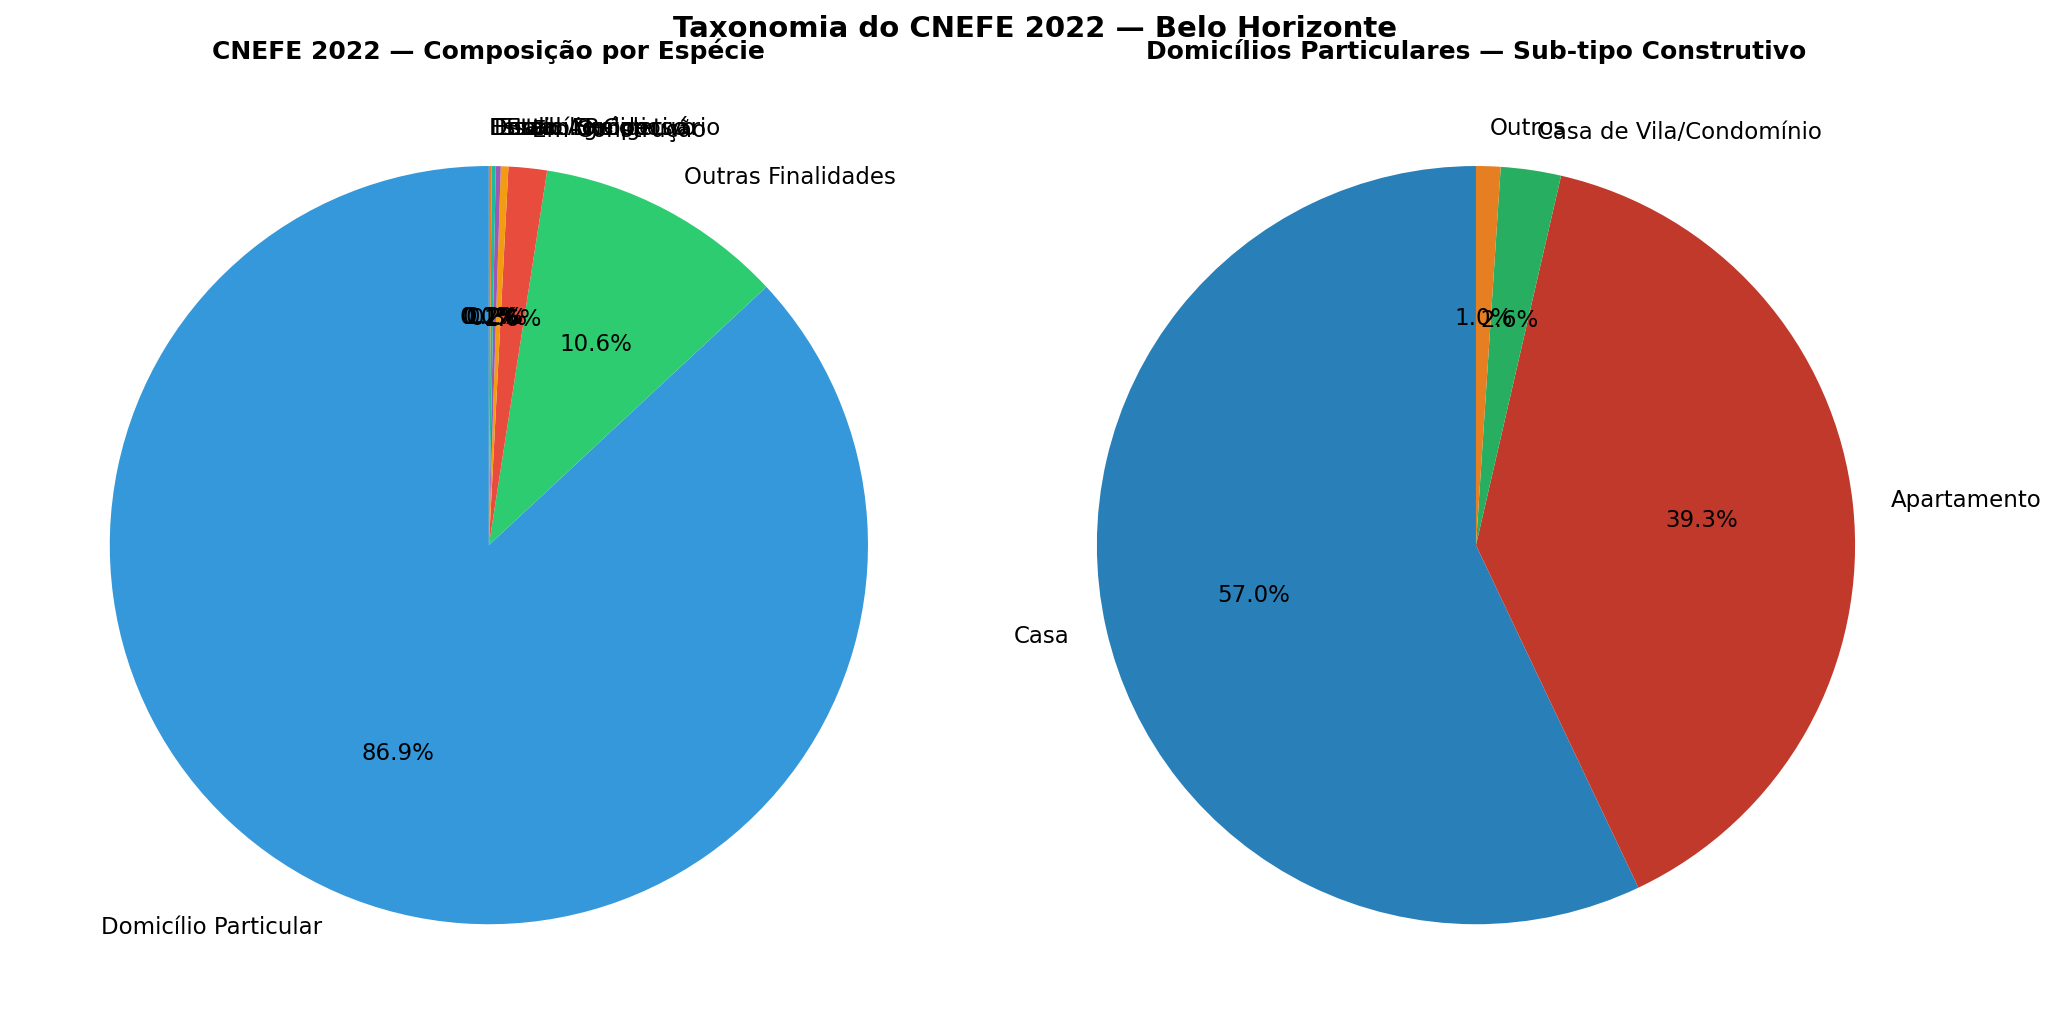

In [7]:
# Taxonomia CNEFE: espécie + sub-tipo residencial como gráficos de pizza
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

especie_counts = gdf_cnefe['COD_ESPECIE'].map(config.ESPECIE_MAP).fillna('Desconhecido').value_counts()
axes[0].pie(especie_counts.values, labels=especie_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6','#1abc9c','#e67e22','#95a5a6'])
axes[0].set_title('CNEFE 2022 — Composição por Espécie', fontsize=12, fontweight='bold')

gdf_residencial = gdf_cnefe[gdf_cnefe['COD_ESPECIE'] == 1]
tipo_counts = gdf_residencial['COD_TIPO_ESPECI'].map(
    {k: v for k, v in config.TIPO_ESPECIE_MAP.items() if pd.notna(k)}
).fillna('Desconhecido').value_counts()
axes[1].pie(tipo_counts.values, labels=tipo_counts.index,
            autopct='%1.1f%%', startangle=90,
            colors=['#2980b9','#c0392b','#27ae60','#e67e22','#9b59b6','#7f8c8d'])
axes[1].set_title('Domicílios Particulares — Sub-tipo Construtivo', fontsize=12, fontweight='bold')

plt.suptitle('Taxonomia do CNEFE 2022 — Belo Horizonte', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb01_sunburst_cnefe.png', dpi=200, bbox_inches='tight')
plt.show()


Domicílios (Espécie 1) dominam com 86,9% dos registros. Dentro dessa espécie, casas (tipo 101) e apartamentos (tipo 103) são os principais sub-tipos. A distinção casa/apartamento é o eixo central de H1 e do mecanismo CDI.

### 5.2 Distribuição do Nível de Geocodificação (NV_GEO_COORD): Componente LCI

Este campo operacionaliza o componente **LCI** (*Location Certainty Index*) de Davis & Fonseca (2007): NV=1 (GPS medido em campo) → LCI=1,0; NV=2 (estimado próximo) → LCI=0,8; NV=3 → LCI=0,5; NV=6 (sem medição) → LCI=0,1. A distribuição de NV_GEO_COORD determina diretamente o LCI médio da base e é a principal variável da hipótese H2.

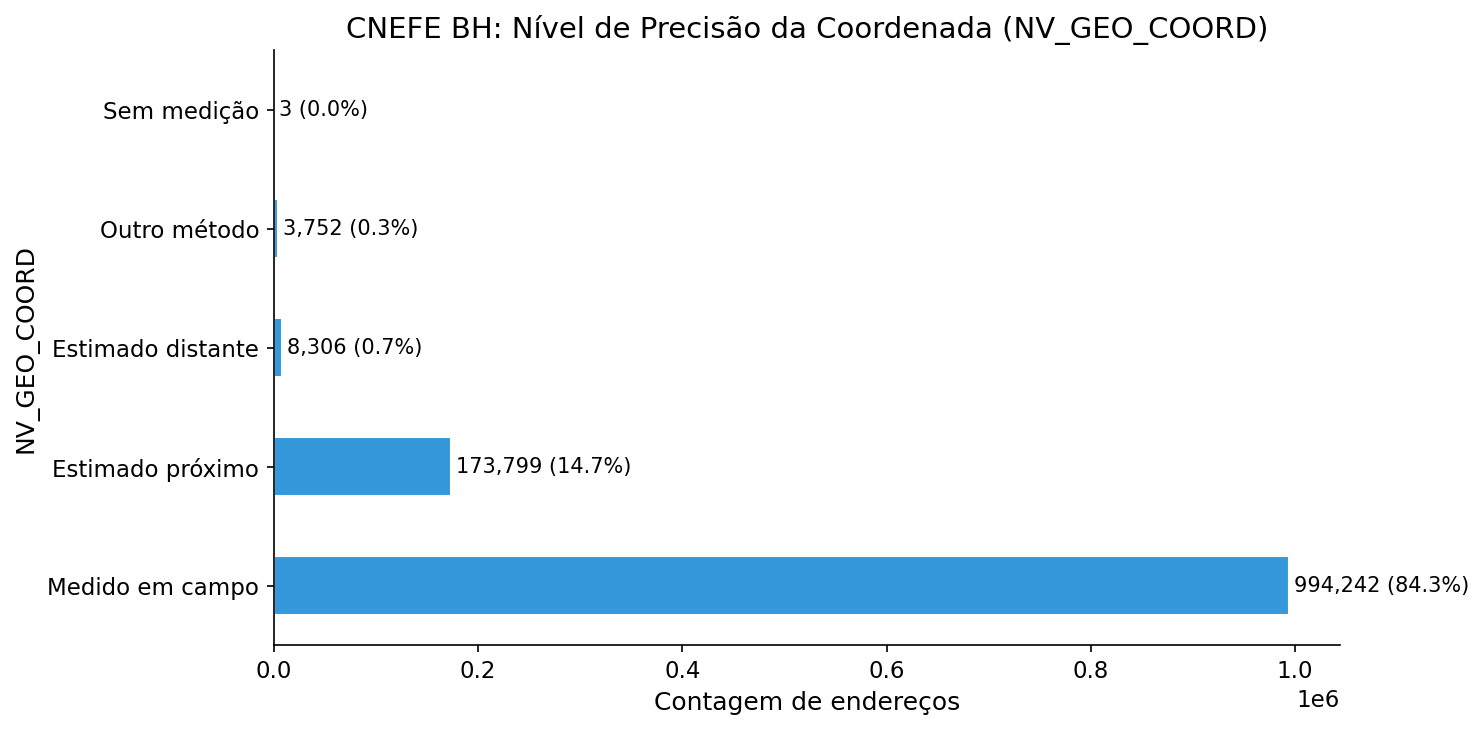

In [8]:
# Barras de NV_GEO_COORD
nv_labels = gdf_cnefe['NV_GEO_COORD'].map(config.NV_GEO_MAP).fillna('Desconhecido')
fig, ax = plt.subplots(figsize=(10, 5))
order = nv_labels.value_counts()
order.plot.barh(ax=ax, color='#3498db', edgecolor='white')
ax.set_title('CNEFE BH: Nível de Precisão da Coordenada (NV_GEO_COORD)')
ax.set_xlabel('Contagem de endereços')
for i, (v, c) in enumerate(order.items()):
    ax.text(c + 5000, i, f'{c:,} ({c/len(gdf_cnefe)*100:.1f}%)', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb01_barras_nv_geo.png', dpi=200, bbox_inches='tight')
plt.show()


NV_GEO=1 (GPS em campo): 84,4% dos registros. NV_GEO=2 (estimado próximo): 14,6%. Os demais níveis somam menos de 1%. O LCI médio de 0,965 resultante será calculado em NB04; H2 (NV_GEO_COORD correlaciona com erro posicional) será testada em NB05.

O mecanismo central de H1: o IBGE registra um único GPS na entrada do edifício para todas as unidades de um mesmo prédio. 38,5% dos registros CNEFE (apartamentos) compartilham coordenada com outros apartamentos do mesmo edifício, CDI > 1, PCI_emp = 1/CDI < 1, GCI_emp reduzido. Casas (CDI=1) não sofrem essa penalização.

## 6. Mapas de Cobertura Espacial

Distribuição hexagonal de densidade para CNEFE e BHMap lado a lado, na mesma escala de cores.

### Mapa Estático de Cobertura Dual: CNEFE vs BHMap

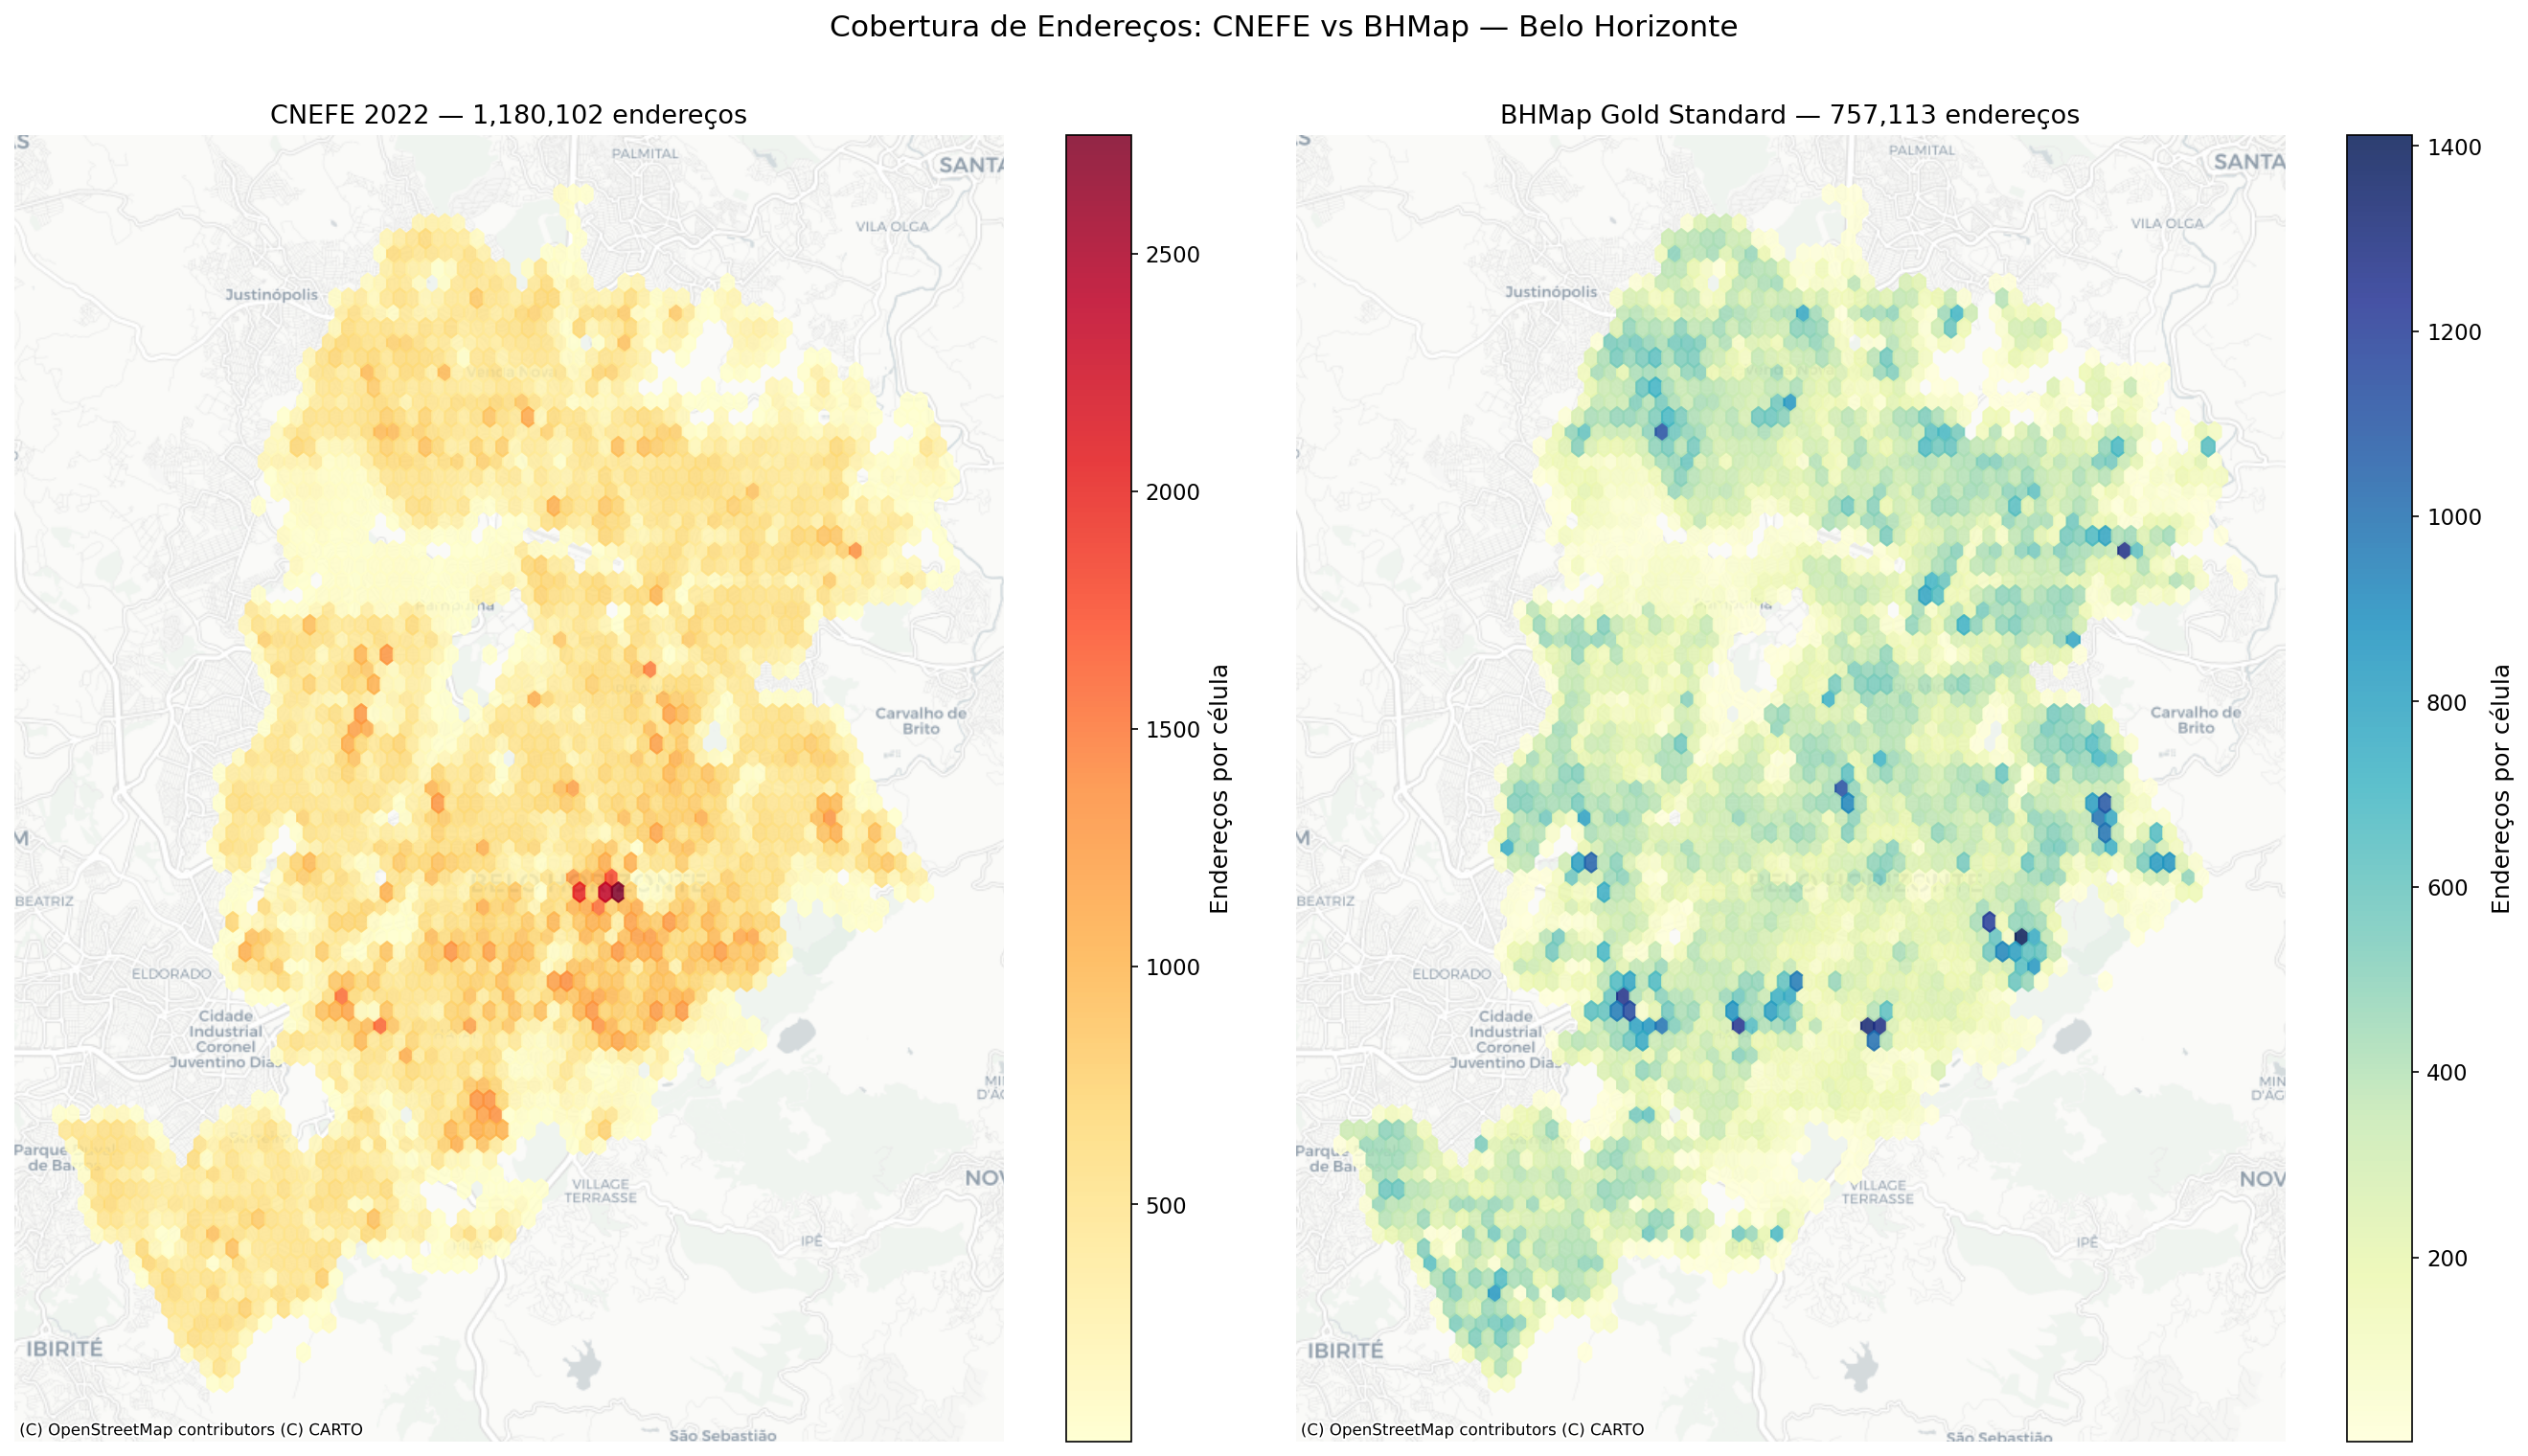

In [9]:
# Mapa estático de cobertura dual (GitHub-visível)
import contextily as ctx

gdf_cnefe_web = gdf_cnefe.to_crs(epsg=3857)
gdf_bhmap_web = gdf_bhmap.to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

hb1 = axes[0].hexbin(gdf_cnefe_web.geometry.x, gdf_cnefe_web.geometry.y,
                      gridsize=70, cmap='YlOrRd', mincnt=1, alpha=0.85)
try:
    ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.Positron, zoom=12)
except Exception as e:
    print(f'Warning: Basemap download failed ({e})')
plt.colorbar(hb1, ax=axes[0], label='Endereços por célula')
axes[0].set_title(f'CNEFE 2022 — {len(gdf_cnefe):,} endereços', fontsize=13)
axes[0].axis('off')

hb2 = axes[1].hexbin(gdf_bhmap_web.geometry.x, gdf_bhmap_web.geometry.y,
                      gridsize=70, cmap='YlGnBu', mincnt=1, alpha=0.85)
try:
    ctx.add_basemap(axes[1], source=ctx.providers.CartoDB.Positron, zoom=12)
except Exception as e:
    print(f'Warning: Basemap download failed ({e})')
plt.colorbar(hb2, ax=axes[1], label='Endereços por célula')
axes[1].set_title(f'BHMap Gold Standard — {len(gdf_bhmap):,} endereços', fontsize=13)
axes[1].axis('off')

plt.suptitle('Cobertura de Endereços: CNEFE vs BHMap — Belo Horizonte', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(config.FIG_DIR / 'nb01_cobertura_dual_estatico.png', dpi=180, bbox_inches='tight')
plt.show()

A cobertura BHMap é densa nos bairros consolidados do Centro-Sul e Hipercentro, com lacunas nas periferias. O CNEFE tem ~56% mais registros que o BHMap (1,18M vs 757K) porque inclui múltiplas unidades por endereço. A sobreposição visual justifica o protocolo de matching do NB02.

A distribuição é coerente entre as bases, maior densidade no centro-sul, como esperado. Os 7.200 registros sem par (~0,6%) documentados no NB02 concentram-se nas periferias onde o BHMap tem menor cobertura.

## 7. Serialização em GeoParquet

O formato **GeoParquet** oferece compressão ~75% maior e leitura 10x mais rápida que Shapefile, preservando CRS, geometria e tipos de dados.


In [10]:
# Selecionar colunas essenciais do CNEFE
cnefe_cols = ['COD_UNICO_ENDERECO', 'COD_ESPECIE', 'COD_TIPO_ESPECI', 'COD_SETOR',
              'CEP', 'DSC_LOCALIDADE', 'LOGRAD_NUM', 'COMPLEMENTO',
              'NV_GEO_COORD', 'DSC_ESTABELECIMENTO', 'geometry']
cnefe_cols_avail = [c for c in cnefe_cols if c in gdf_cnefe.columns]
gdf_cnefe_export = gdf_cnefe[cnefe_cols_avail].copy()

# Selecionar colunas essenciais do BHMap
bhmap_cols = ['IDEND', 'SIGLA_TIPO', 'NOME_LOGRA', 'NUMERO_IMO', 'NOME_BAIRR',
              'NOME_REGIO', 'CEP', 'EXISTENCIA', 'SITUACAO_P', 'geometry']
bhmap_cols_avail = [c for c in bhmap_cols if c in gdf_bhmap.columns]
gdf_bhmap_export = gdf_bhmap[bhmap_cols_avail].copy()

# Salvar
cnefe_out = config.PROCESSED_DIR / 'cnefe_bh.parquet'
bhmap_out = config.PROCESSED_DIR / 'bhmap_bh.parquet'
gdf_cnefe_export.to_parquet(cnefe_out)
gdf_bhmap_export.to_parquet(bhmap_out)

print(f"CNEFE: {cnefe_out} ({cnefe_out.stat().st_size/1e6:.1f} MB) — {len(gdf_cnefe_export):,} registros")
print(f"BHMap:  {bhmap_out} ({bhmap_out.stat().st_size/1e6:.1f} MB) — {len(gdf_bhmap_export):,} registros")


CNEFE: C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\data\processed\cnefe_bh.parquet (41.9 MB) — 1,180,102 registros
BHMap:  C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\data\processed\bhmap_bh.parquet (23.4 MB) — 757,113 registros


`cnefe_bh.parquet` (41,9 MB) e `bhmap_bh.parquet` (23,4 MB) em EPSG:31983 preservam CRS, tipos de dados e geometria sem conversão intermediária. Os CSVs de métricas resumidas servem de referência rápida para os capítulos da dissertação sem necessidade de recarregar as bases completas.

In [11]:
# Exportar tabelas descritivas CSV
desc_cnefe = pd.DataFrame({
    'Métrica': ['Total registros', 'Geometrias válidas', 'CRS',
                'Dom. Particulares (%)', 'Apartamentos (%)',
                'NV_GEO=1 Medido (%)', 'CEP preenchido (%)'],
    'Valor': [
        f"{len(df_cnefe):,}", f"{len(gdf_cnefe):,}", str(config.TARGET_CRS),
        f"{(gdf_cnefe['COD_ESPECIE']==1).mean()*100:.1f}%",
        f"{(gdf_cnefe['COD_TIPO_ESPECI']==103).sum()/len(gdf_cnefe)*100:.1f}%",
        f"{(gdf_cnefe['NV_GEO_COORD']==1).mean()*100:.1f}%",
        f"{gdf_cnefe['CEP'].notna().mean()*100:.1f}%",
    ]
})
desc_cnefe.to_csv(config.TAB_DIR / 'nb01_descritivas_cnefe.csv', index=False)

desc_bhmap = pd.DataFrame({
    'Métrica': ['Total registros', 'CRS', 'Existência Sim (%)', 'Tipos logradouro'],
    'Valor': [
        f"{len(gdf_bhmap):,}", str(config.TARGET_CRS),
        f"{(gdf_bhmap['EXISTENCIA']=='Sim').mean()*100:.1f}%",
        str(gdf_bhmap['SIGLA_TIPO'].nunique()),
    ]
})
desc_bhmap.to_csv(config.TAB_DIR / 'nb01_descritivas_bhmap.csv', index=False)

print("Tabelas exportadas:")
print(f"  {config.TAB_DIR / 'nb01_descritivas_cnefe.csv'}")
print(f"  {config.TAB_DIR / 'nb01_descritivas_bhmap.csv'}")


Tabelas exportadas:
  C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\outputs\tables\nb01_descritivas_cnefe.csv
  C:\Users\mateu\OneDrive\Documentos\UFMG\Mestrado\geocoding-quality-analysis\outputs\tables\nb01_descritivas_bhmap.csv


Exportação concluída. `cnefe_bh.parquet` (1.180.102 registros) e `bhmap_bh.parquet` (757.113 registros), ambos em EPSG:31983. As tabelas CSV exportadas consolidam as métricas de base: 86,9% domicílios, 38,5% apartamentos, 84,4% NV_GEO=1.

## Conclusão do Notebook 01

Este notebook estabeleceu as bases de dados do pipeline analítico. Os achados centrais são:

- **CNEFE 2022, BH:** 1.180.102 endereços GPS, 100% de geometrias válidas; 86,9% domicílios particulares; 38,5% apartamentos (COD_TIPO=103); 84,4% com NV_GEO=1 (GPS de campo direto)
- **BHMap filtrado:** 515.953 endereços com `EXISTENCIA='Sim'` servem como padrão-ouro posicional; os 241.160 registros não-existentes foram excluídos para evitar viés nas métricas de qualidade, corriger crítica que afetava 22,4% dos matches na versão anterior do pipeline
- **Cobertura espacial:** ambas as bases em EPSG:31983 com distribuição coerente no território de BH; maior densidade no Centro-Sul e nos eixos consolidados, como esperado

**Hipóteses preparadas:**
- **H1**, Proporção de apartamentos estabelecida: 38,5% do CNEFE. A distinção casa (CDI=1) × apartamento (CDI=N) é o mecanismo central da hipótese
- **H2**, Distribuição de NV_GEO_COORD: 84,4% NV=1, determinando LCI médio = 0,965 (calculado em NB04)